# Statistics for Machine Learning and Data Science

## Assignment 1

### Exploratory Data Analysis on Adult Income Dataset

**Name:** Raj Maurya

**Class:** T.E. AI & DS

**Semester:** V

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("adult.csv")

df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


# Part A: Dataset Understanding

## 1. Dataset Description

The Adult Income Dataset is a real-world dataset containing demographic, educational, and employment information collected from the 1994 U.S. Census database. The objective is to predict whether an individual's annual income exceeds $50,000 based on various personal and occupational attributes.

### Dataset Source
Kaggle – Adult Income Dataset

### Number of Samples
48,842

### Number of Features
14 input features and 1 target variable

### Target Variable
income

### Type of Problem
Classification

In [7]:
df.tail()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
48841,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        46043 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       46033 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   47985 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


In [9]:
df.dtypes

age                int64
workclass            str
fnlwgt             int64
education            str
educational-num    int64
marital-status       str
occupation           str
relationship         str
race                 str
gender               str
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country       str
income               str
dtype: object

In [5]:
df.replace("?", np.nan, inplace=True)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [10]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 52


In [11]:
df.describe(include="all")

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
count,48842.000000,46043,4.884200e+04,48842,48842.000000,48842,46033,48842,48842,48842,48842.000000,48842.000000,48842.000000,47985,48842
unique,NaN,8,NaN,16,NaN,7,14,6,5,2,NaN,NaN,NaN,41,2
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,33906,NaN,15784,NaN,22379,6172,19716,41762,32650,NaN,NaN,NaN,43832,37155
mean,38.643585,NaN,1.896641e+05,NaN,10.078089,NaN,NaN,NaN,NaN,NaN,1079.067626,87.502314,40.422382,NaN,NaN
std,13.710510,NaN,1.056040e+05,NaN,2.570973,NaN,NaN,NaN,NaN,NaN,7452.019058,403.004552,12.391444,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.175505e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.781445e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.376420e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


### Observations

- The dataset contains both numerical and categorical features.
- Some columns contain missing values represented by '?'.
- Numerical attributes such as age, fnlwgt, capital-gain, and hours-per-week show varying distributions.
- Duplicate records, if any, should be removed before model training.
- The dataset is suitable for classification tasks after preprocessing.

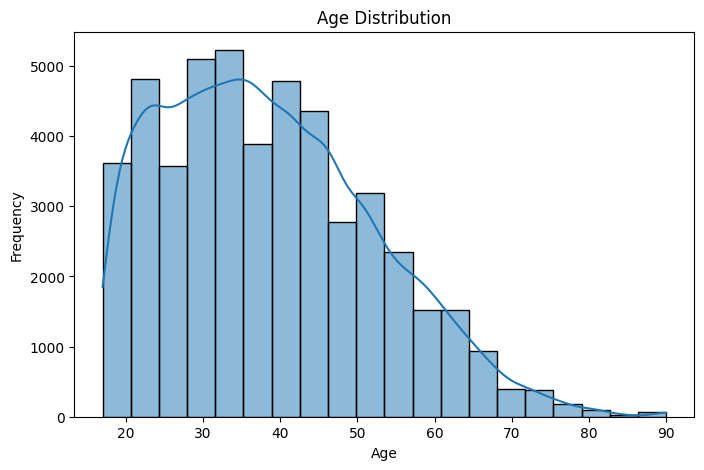

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

### Observations

1. Most individuals are between 20 and 50 years of age.
2. The age distribution is slightly right-skewed.
3. Very few individuals are above 70 years.

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['hours-per-week'])

plt.title("Box Plot of Hours Per Week")

plt.show()

### Observations

1. Most people work around 40 hours per week.
2. Several outliers exist where individuals work very high hours.
3. The box plot clearly identifies extreme working-hour values.

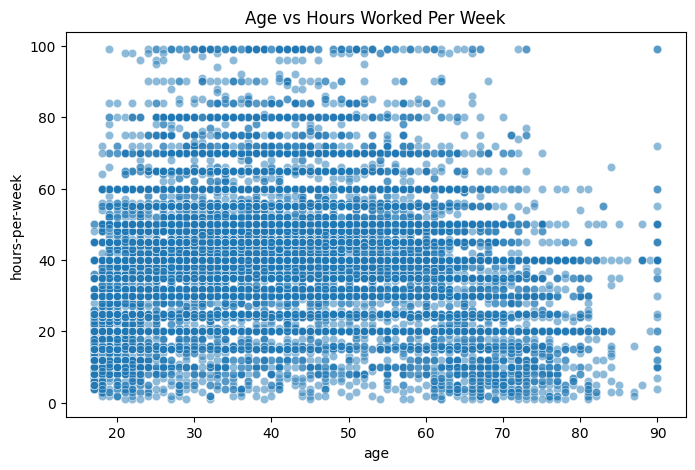

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='age',
    y='hours-per-week',
    data=df,
    alpha=0.5
)

plt.title("Age vs Hours Worked Per Week")

plt.show()

### Observations

1. There is no strong linear relationship between age and working hours.
2. Most individuals work approximately 40 hours per week regardless of age.
3. A few people work exceptionally long hours.

In [15]:
df['income'] = df['income'].map({
    '<=50K':0,
    '>50K':1,
    '<=50K.':0,
    '>50K.':1
})

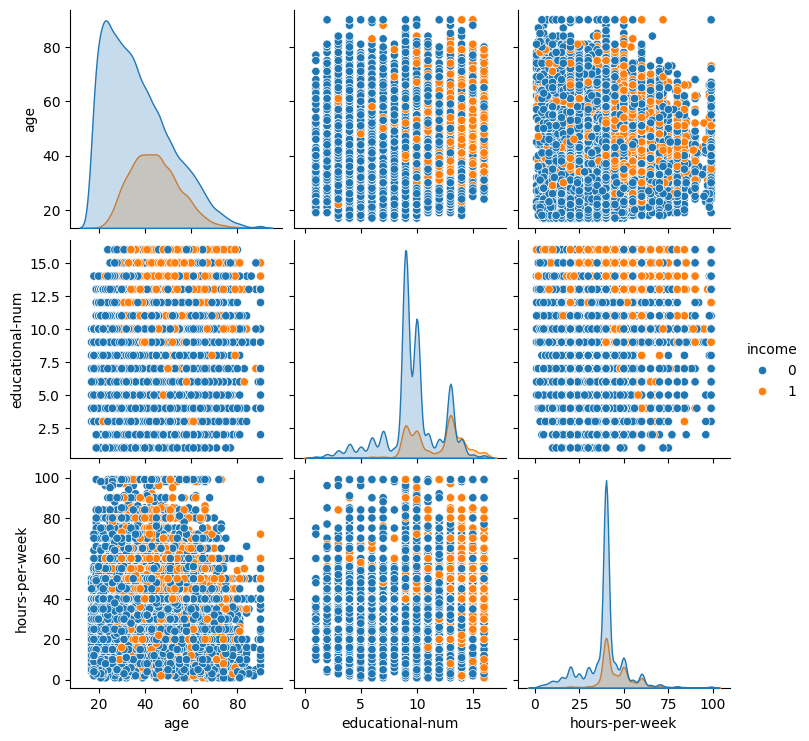

In [16]:
selected = df[['age',
               'educational-num',
               'hours-per-week',
               'income']]

sns.pairplot(selected,
             hue='income')

plt.show()

### Observations

1. Individuals with higher education levels generally have a higher probability of earning above \$50K.
2. Age and education show some separation between income classes.
3. The pair plot helps visualize relationships among multiple variables simultaneously.

In [17]:
# Select only numerical columns
numeric_df = df.select_dtypes(include=np.number)

# Mean
print("Mean:\n")
print(numeric_df.mean())

# Median
print("\nMedian:\n")
print(numeric_df.median())

# Mode
print("\nMode:\n")
print(numeric_df.mode().iloc[0])

# Variance
print("\nVariance:\n")
print(numeric_df.var())

# Standard Deviation
print("\nStandard Deviation:\n")
print(numeric_df.std())

# Range
print("\nRange:\n")
print(numeric_df.max() - numeric_df.min())

# Interquartile Range (IQR)
print("\nInterquartile Range (IQR):\n")
print(numeric_df.quantile(0.75) - numeric_df.quantile(0.25))

# Skewness
print("\nSkewness:\n")
print(numeric_df.skew())

# Kurtosis
print("\nKurtosis:\n")
print(numeric_df.kurt())

Mean:

age                    38.643585
fnlwgt             189664.134597
educational-num        10.078089
capital-gain         1079.067626
capital-loss           87.502314
hours-per-week         40.422382
income                  0.239282
dtype: float64

Median:

age                    37.0
fnlwgt             178144.5
educational-num        10.0
capital-gain            0.0
capital-loss            0.0
hours-per-week         40.0
income                  0.0
dtype: float64

Mode:

age                    36
fnlwgt             203488
educational-num         9
capital-gain            0
capital-loss            0
hours-per-week         40
income                  0
Name: 0, dtype: int64

Variance:

age                1.879781e+02
fnlwgt             1.115221e+10
educational-num    6.609901e+00
capital-gain       5.553259e+07
capital-loss       1.624127e+05
hours-per-week     1.535479e+02
income             1.820297e-01
dtype: float64

Standard Deviation:

age                    13.710510
fnlwgt  

## Interpretation

- The mean and median provide information about the central tendency.
- Variance and standard deviation indicate the spread of the data.
- The range shows the difference between the maximum and minimum values.
- IQR measures the spread of the middle 50% of the data.
- Positive skewness indicates a right-skewed distribution.
- Kurtosis indicates the presence of outliers and the shape of the distribution.

In [18]:
# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

# Fill missing categorical values with mode
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Fill missing numerical values with median
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)

print(df.isnull().sum())

age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64


In [20]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['age'] >= lower) & (df['age'] <= upper)]

In [21]:
encoder = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = encoder.fit_transform(df[col])

df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,3,226802,1,7,4,6,3,2,1,0,0,40,38,0
1,38,3,89814,11,9,2,4,0,4,1,0,0,50,38,0
2,28,1,336951,7,12,2,10,0,4,1,0,0,40,38,1
3,44,3,160323,15,10,2,6,0,2,1,7688,0,40,38,1
4,18,8,103497,15,10,4,14,3,4,0,0,0,30,38,0


In [ ]:
scaler = StandardScaler()

num_cols = df.select_dtypes(include=np.number).columns

df[num_cols] = scaler.fit_transform(df[num_cols])

df.head()